# Import paths and taxonomy viz

In [6]:
import pandas as pd
from pathlib import Path
from datetime import datetime
from typing import Optional,Sequence
import os
import shutil
import sys
sys.path.append("../")

from langgraph.checkpoint.sqlite import SqliteSaver
from IPython.display import display


from experiment_utils import copy_folder,compute_experiment_result,plot_aggregated_metrics,plot_taxonomy_difficulty,get_token_levels_index
from adam_python.agentic_forge.checkpointers import SqliteSaver,forge_checkpointer,CheckpointerConfig



EXP_NAME=Path("experiments")


SRC_DATA_PATH=Path("../adam_unity/Assets/BenchmarkData") /EXP_NAME #This should be concatenated with the name of the experiment
SRC_DATA_PATH=Path("../adam_unity/Build/ADAMO_Build_Data/BenchmarkData") /EXP_NAME #This should be concatenated with the name of the experiment
DST_DATA_PATH=Path("./final_experiments/") / EXP_NAME
#DST_DATA_PATH=Path("./experiments/")

CHECKPOINTER_DB_PATH=Path("../adam_python/checkpoints/checkpoint.db")
CHECKPOINTER_CONF_PATH=Path("../adam_python/agentic_forge/configs/checkpointer_config.yaml")

EP_DEF_YAML=Path("../episodes_definition.yaml")
dst_folder=DST_DATA_PATH

#_,_=plot_taxonomy_difficulty(EP_DEF_YAML)

# Copy from data to experiment (only for analyze current run)

- If source folder already have timestamp set timestamp_fmt to None
- If you want to analyze already copied results (derived from auomated benchmark runs) avoid to copy

In [2]:
dst_folder=DST_DATA_PATH
print(dst_folder)
dst_folder=copy_folder(SRC_DATA_PATH,DST_DATA_PATH,exclude_exts=[".meta",".jpg",".log"],timestamp_fmt=None)

experiments\gpt_scene2


# Load the saver to retrieve the chekpoints

- Fix the path of the db relative to this script to get the saver
- compute the tables for each episode repetions and aggregate over the repetitions, save it in the experiment folder (DST_DATA_PATH)
    - if the metrics are already computed set compute_experiment_result(from_csv=True)
- plot some metrics

In [3]:
import pandas as pd
from pathlib import Path
from datetime import datetime
from typing import Optional,Sequence
import os
import shutil
import sys
sys.path.append("../")

from langgraph.checkpoint.sqlite import SqliteSaver
from IPython.display import display


from experiment_utils import get_token_levels_index,copy_folder,compute_experiment_result,plot_aggregated_metrics,plot_taxonomy_difficulty,get_token_levels_index,plot_completion_rate_by_episode
from adam_python.agentic_forge.checkpointers import SqliteSaver,forge_checkpointer,CheckpointerConfig



EXP_NAME=Path("final_experiments")


SRC_DATA_PATH=Path("../adam_unity/Assets/BenchmarkData") /EXP_NAME #This should be concatenated with the name of the experiment
SRC_DATA_PATH=Path("../adam_unity/Build/ADAMO_Build_Data/BenchmarkData") /EXP_NAME #This should be concatenated with the name of the experiment
DST_DATA_PATH=Path("./final_experiments/") / EXP_NAME

CHECKPOINTER_DB_PATH=Path("../adam_python/checkpoints/checkpoint.db")
CHECKPOINTER_CONF_PATH=Path("../adam_python/agentic_forge/configs/checkpointer_config.yaml")

EP_DEF_YAML=Path("../episodes_definition.yaml")
dst_folder=DST_DATA_PATH

dst_folder

cfg=CheckpointerConfig.from_yaml(CHECKPOINTER_CONF_PATH)
cfg.config.path=Path(CHECKPOINTER_DB_PATH)
saver:SqliteSaver=forge_checkpointer(cfg)
#dst_folder="./experiments/exp_default"

c:\Users\Alessandro Pecora\Desktop\adam_project\adam_experiments\..\adam_python\agentic_forge\configs\base_config.py:54: UserWarning: [CheckpointerConfig] Auto-extracted config from key 'checkpointer'
  warnings.warn(


In [10]:
out_agg[out_agg.taskId=="T12"][["tax","taskId"]]

,tax,taskId
12,NaN,T12
13,NaN,T12
14,NaN,T12
15,NaN,T12
72,10.0,T12
73,10.0,T12
74,10.0,T12
75,10.0,T12


Computing results for each episode repetitions: 100%|██████████| 120/120 [04:51<00:00,  2.43s/it]
c:\Users\Alessandro Pecora\Desktop\adam_project\adam_experiments\experiment_utils.py:813: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  tmp[c] = pd.to_numeric(tmp[c], errors="ignore")
c:\Users\Alessandro Pecora\Desktop\adam_project\adam_experiments\experiment_utils.py:813: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  tmp[c] = pd.to_numeric(tmp[c], errors="ignore")
c:\Users\Alessandro Pecora\Desktop\adam_project\adam_experiments\experiment_utils.py:813: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  tmp[c] = pd.to_numeric(tmp[c], errors="ignore")

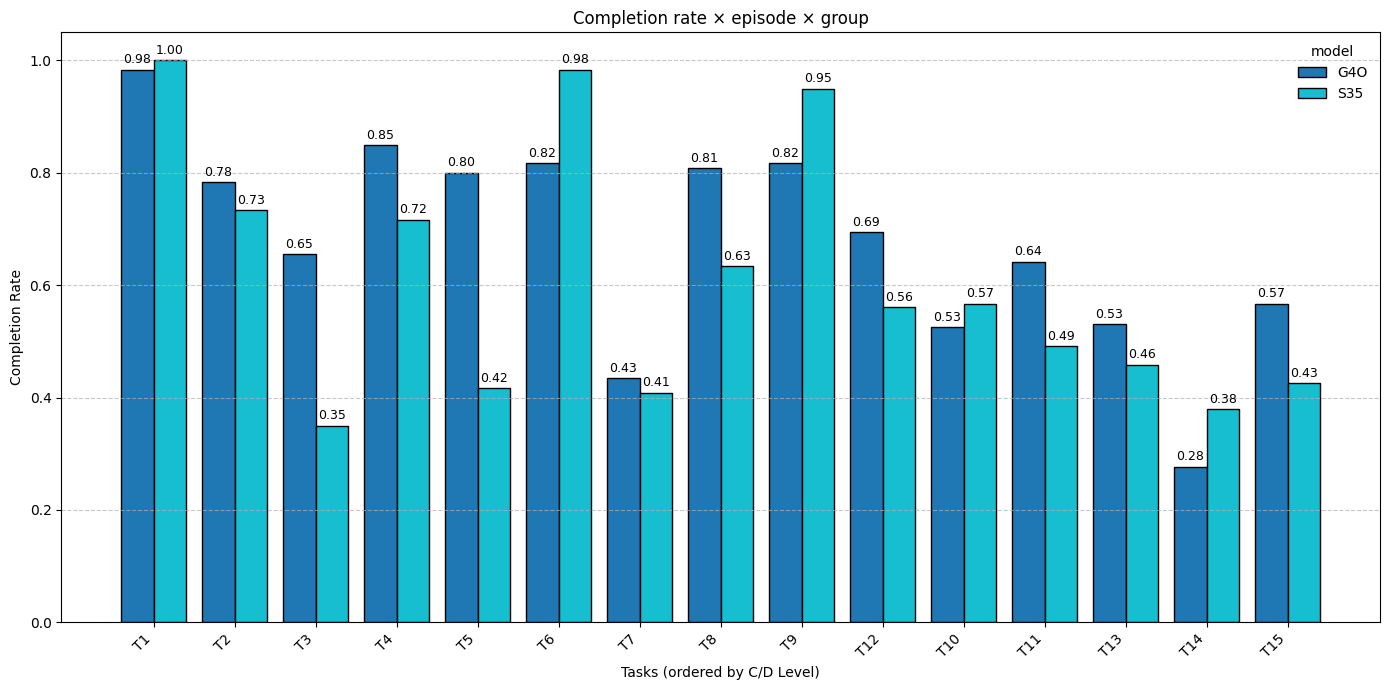

_group,G4O,S35
episode_label,,
T1,0.983333,1.000000
T2,0.783333,0.733333
T3,0.654762,0.350000
T4,0.848810,0.716667
T5,0.800000,0.416667
T6,0.816667,0.983333
T7,0.434733,0.408767
T8,0.808333,0.633333
T9,0.816667,0.950000


In [4]:


out_all,out_agg=compute_experiment_result(dst_folder,saver) #,save=False,from_csv=True)
plot_completion_rate_by_episode(out_agg)



# Check taxonomy difficulty for the task

In [ ]:
get_token_levels_index(EP_DEF_YAML)["S1"]["T1"]

In [ ]:
tax_cols=[col for col in out_all.columns if "tax" in col]
out_all[["scene","taskId"]+tax_cols]

## Compare required actions Act dimension fo the taxonomy with toolCalls for action

In [ ]:
tax_cols=[col for col in out_all.columns if "toolCalls" in col or "taxAct" in col]
out_all[["scene","taskId","solutionCheck","taskPrompt","threadId"]+tax_cols]

In [ ]:
plot_aggregated_metrics(out_agg, ["model"])

In [ ]:
out_all[["scene","taskId","solutionCheck","taskPrompt","threadId"]+tax_cols]

In [ ]:
tax_cols=[col for col in out_all.columns if "tax" in col]
df = out_agg[["taskId","solutionCheck","model"]+tax_cols]

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the basic plot with lines and markers
fig, ax = plt.subplots(figsize=(12, 8))
sns.lineplot(
    data=df,
    x='tax',
    y='solutionCheck',
    hue='model',    # Creates a separate colored line for each model
    marker='o',     # Adds a marker for each data point
    ax=ax
)

# 2. Add the "taskId" labels to each point
# We loop through each row of the DataFrame to get the coordinates and the label
for index, row in df.iterrows():
    ax.text(
        row['tax'] + 0.5, # x-coordinate for the text (with a small offset)
        row['solutionCheck'], # y-coordinate for the text
        row['taskId'], # The text label itself
        fontsize=9
    )

# 3. Customize and show the plot
ax.set_title('solutionCheck vs. tax by Model')
ax.set_xlabel('Tax Value')
ax.set_ylabel('solutionCheck Value')
ax.grid(True)
plt.legend(title='Model')
plt.show()

In [ ]:
tax_cols=[col for col in out_all.columns if "tax" in col]
df = out_all[["taskId","solutionCheck","model"]+tax_cols]

# Calculate the correlation matrix for the two columns
correlation_matrix = df[['tax', 'solutionCheck']].corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Get the specific coefficient between tax and solutionCheck
correlation_coefficient = correlation_matrix.loc['tax', 'solutionCheck']

print(f"\nCorrelation Coefficient: {correlation_coefficient:.2f}")

In [ ]:
_,_=plot_aggregated_metrics(out_agg[out_agg["model"] == "G4O"])

In [ ]:
out_agg

In [ ]:
_,_=plot_aggregated_metrics(out_agg[out_agg["model"] == "S35"])

In [ ]:
df_stat_model,_=plot_aggregated_metrics(out_agg,by=["model"])

In [ ]:
df_stat_model

In [ ]:
df_stat,_=plot_aggregated_metrics(out_agg,by=["model","scene","taskId"])

In [ ]:
df_stat

In [ ]:
_,_=plot_aggregated_metrics(out_agg,by=["scene","taskId"])

In [ ]:
_,_=plot_aggregated_metrics(out_agg,by=["model","taxRef"])